#### **Table of Contents**

**Setup**

1. [Load Preprocessed Data](#load-data)
2. [Evaluation Strategy](#evaluation-strategy)

**Model Development**

3. [Baseline Model](#baseline)
4. [Model Spot-Check](#spot-check)
5. [Full Features vs PCA](#full-vs-pca)
6. [Hyperparameter Tuning](#tuning)
7. [Ensembling](#ensembling)

**Evaluation**

8. [Final Test-Set Evaluation](#final-evaluation)
9. [Residual Diagnostics](#residuals)
10. [Feature Importance](#feature-importance)

**Deployment Preparation**

11. [Save Final Model](#save-model)

**Conclusion**

12. [Summary](#summary)

## 1. Load Preprocessed Data <a name="load-data"></a>

All preprocessing was completed in `Feature_Engineering_.ipynb` and exported to disk. Nothing is re-derived here -- this notebook consumes those artifacts as-is, which is what keeps the leakage discipline established there intact: every fitted quantity (scaler, encoder columns, PCA, rare-category list) came from `X_train` only, and `X_test` has not been touched since.

**Target convention:** models are trained and cross-validated on `y_train_log` = `log1p(SalePrice)`, per the EDA decision table. Raw-dollar `y_train` / `y_test` are loaded only for reporting predictions back on the original scale in Section 8.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

RANDOM_STATE = 42

# Feature matrices
X_train = pd.read_csv("X_train_final.csv")
X_test = pd.read_csv("X_test_final.csv")

# PCA-reduced variants (exploratory alternative, compared in Section 5)
X_train_pca = pd.read_csv("X_train_pca.csv")
X_test_pca = pd.read_csv("X_test_pca.csv")

# Targets. .squeeze() converts the single-column DataFrames back to Series.
y_train_log = pd.read_csv("y_train_log.csv").squeeze("columns")
y_test_log = pd.read_csv("y_test_log.csv").squeeze("columns")
y_train = pd.read_csv("y_train.csv").squeeze("columns")   # raw dollars, reporting only
y_test = pd.read_csv("y_test.csv").squeeze("columns")     # raw dollars, reporting only

print(f"X_train      : {X_train.shape}")
print(f"X_test       : {X_test.shape}")
print(f"X_train_pca  : {X_train_pca.shape}")
print(f"X_test_pca   : {X_test_pca.shape}")
print(f"y_train_log  : {y_train_log.shape}")
print(f"y_test_log   : {y_test_log.shape}")

X_train      : (2342, 219)
X_test       : (586, 219)
X_train_pca  : (2342, 30)
X_test_pca   : (586, 30)
y_train_log  : (2342,)
y_test_log   : (586,)


In [2]:
# Environment & reproducibility
import sys, sklearn, pandas, numpy, matplotlib, seaborn
print(f"Python      {sys.version.split()[0]}")
print(f"numpy       {numpy.__version__}")
print(f"pandas      {pandas.__version__}")
print(f"sklearn     {sklearn.__version__}")
print(f"matplotlib  {matplotlib.__version__}")
print(f"seaborn     {seaborn.__version__}")
print()
print("Source notebooks : EDA_.ipynb → Feature_Engineering_.ipynb → Modeling_.ipynb")
print("Cleaned data     : AmesHousing_cleaned.csv (Dean De Cock Ames dataset)")
print("Split            : 80/20 train/test, random_state=42, no stratification")
print(f"n_train={len(X_train):,}  n_test={len(X_test):,}  features={X_train.shape[1]}")
print(f"y_train_log  mean={y_train_log.mean():.3f}  std={y_train_log.std():.3f}")
print(f"y_test_log   mean={y_test_log.mean():.3f}  std={y_test_log.std():.3f}")

Python      3.12.3
numpy       2.2.5
pandas      2.3.3
sklearn     1.7.2
matplotlib  3.10.7
seaborn     0.13.2

Source notebooks : EDA_.ipynb → Feature_Engineering_.ipynb → Modeling_.ipynb
Cleaned data     : AmesHousing_cleaned.csv (Dean De Cock Ames dataset)
Split            : 80/20 train/test, random_state=42, no stratification
n_train=2,342  n_test=586  features=219
y_train_log  mean=12.012  std=0.401
y_test_log   mean=12.058  std=0.431


In [3]:
# Confirm the artifacts are mutually consistent before training anything on them
assert list(X_train.columns) == list(X_test.columns), "Train/test feature columns differ"
assert len(X_train) == len(y_train_log) == len(y_train), "Train row counts differ"
assert len(X_test) == len(y_test_log) == len(y_test), "Test row counts differ"
assert X_train.isnull().sum().sum() == 0 and X_test.isnull().sum().sum() == 0, "Nulls present"

print("All consistency checks passed.")

All consistency checks passed.


## 2. Evaluation Strategy <a name="evaluation-strategy"></a>

**Metric: RMSE on `log1p(SalePrice)`**, as fixed in the EDA decision table. Because the target is logged, this metric measures *proportional* error rather than absolute dollar error -- being \$20k off on a \$500k house is penalised roughly the same as being \$8k off on a \$200k house. That is the appropriate treatment for a right-skewed price target, and it's why the log transform and the metric were chosen together rather than independently.

**Validation: 5-fold `KFold` cross-validation within `X_train`.** This is the "CV" referred to in the feature-engineering notebook -- a resampling procedure over the training set, not a separate held-out partition. Every model-selection and tuning decision below is made on CV scores alone.

**`X_test` is not touched until Section 8.** It is used exactly once, to report final performance. Any use of it to choose between models would turn it into a second validation set and inflate the reported score.

In [4]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Shared CV splitter -- the same folds for every model, so comparisons are like-for-like
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def cv_rmse(model, X, y, cv=cv):
    """Mean and std of RMSE across CV folds (on the log-price scale)."""
    # sklearn maximises scores, so RMSE is returned negated -- flip the sign back.
    scores = -cross_val_score(
        model, X, y, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1
    )
    return scores.mean(), scores.std()


print(f"CV scheme: {cv.get_n_splits()}-fold, shuffled, random_state={RANDOM_STATE}")

CV scheme: 5-fold, shuffled, random_state=42


## 3. Baseline Model <a name="baseline"></a>

Two reference points, established before any real modeling, so later scores have something to be judged against:

1. **Dummy (mean) predictor** -- always predicts the training mean. Any model that cannot beat this has learned nothing.
2. **Plain linear regression** -- the simplest model that actually uses the features. This is the bar that added complexity has to justify itself against.

In [5]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

baselines = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
}

baseline_results = []
for name, model in baselines.items():
    mean_rmse, std_rmse = cv_rmse(model, X_train, y_train_log)
    baseline_results.append({"Model": name, "CV RMSE": mean_rmse, "Std": std_rmse})

baseline_df = pd.DataFrame(baseline_results).sort_values("CV RMSE")
display(baseline_df.round(4))

,Model,CV RMSE,Std
1,Linear Regression,0.1310,0.0135
0,Dummy (mean),0.4016,0.0146


**Observation:** the dummy predictor's RMSE is effectively the standard deviation of `log1p(SalePrice)` -- the error you get from ignoring the features entirely. Linear regression improves substantially on it, confirming the engineered feature set carries real signal. Note, though, that ordinary least squares is a poor fit for this particular matrix: with ~85 columns, many of them one-hot dummies and several flagged for multicollinearity in feature engineering, unregularised coefficients can swing wildly. That is precisely what the regularised models in the next section address.

## Learning Curves <a name="learning-curves"></a>

Learning curves reveal whether errors are dominated by **bias** (both train and CV high — need a richer model) or **variance** (train low, CV high, gap not closing — need more data or regularization). They also expose silent data leakage: a train RMSE that never rises as training size grows usually means a fitted quantity (scaler, encoder) was computed outside the fold.

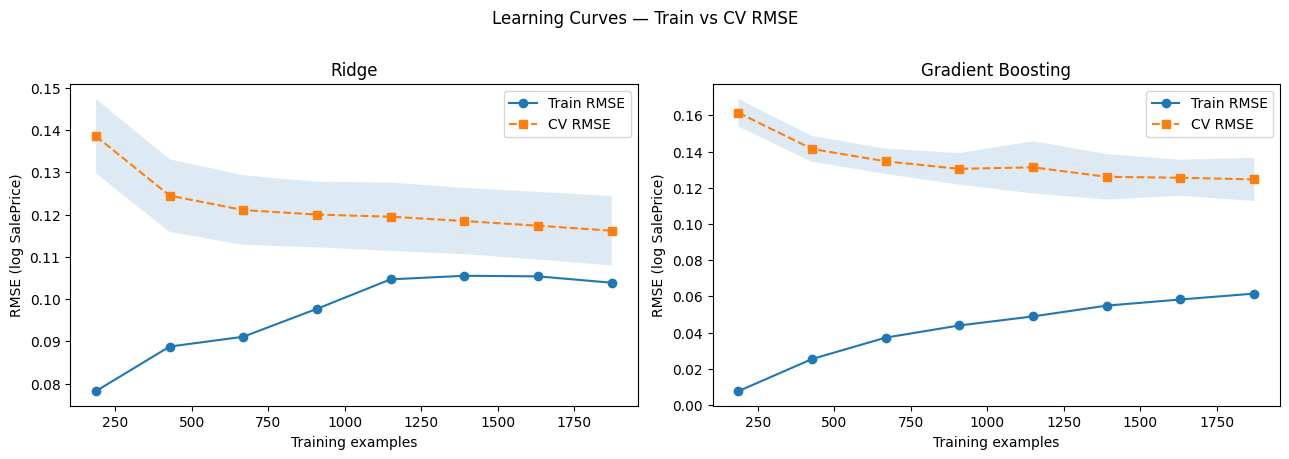

In [7]:
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor

# Use the best linear and best tree model for the comparison
lc_models = {
    "Ridge": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
    ),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (name, model) in zip(axes, lc_models.items()):
    train_sizes, train_scores, cv_scores = learning_curve(
        model, X_train, y_train_log,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=1,
    )
    tr = -train_scores.mean(axis=1)
    cv_ = -cv_scores.mean(axis=1)
    cv_std = cv_scores.std(axis=1)

    ax.plot(train_sizes, tr, "o-", label="Train RMSE")
    ax.plot(train_sizes, cv_, "s--", label="CV RMSE")
    ax.fill_between(train_sizes, cv_ - cv_std, cv_ + cv_std, alpha=0.15)
    ax.set_title(name)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("RMSE (log SalePrice)")
    ax.legend()

plt.suptitle("Learning Curves — Train vs CV RMSE", y=1.01)
plt.tight_layout()
plt.show()

**Bias/variance reading:** if the CV curve has flattened and the gap to train RMSE is large, adding more training data won't help — a richer model or interaction features will. If the gap is small and CV is still falling, collecting more data (or using the full dataset for CV rather than a 20% hold-out) is the right lever.

## 4. Model Spot-Check <a name="spot-check"></a>

Rather than committing to one algorithm up front, a spread of model families is cross-validated at default (or lightly sensible) settings to see which are worth tuning. Three families are represented, each making different assumptions about the data:

- **Regularised linear** (`Ridge`, `Lasso`, `ElasticNet`) -- assume an additive, linear relationship, and shrink coefficients to control the multicollinearity carried over from feature engineering. These benefit directly from the log transforms and scaling applied there.
- **Tree ensembles** (`RandomForest`, `GradientBoosting`, `HistGradientBoosting`) -- capture interactions and non-linearity automatically, and are insensitive to monotonic transforms and feature scaling (so the preprocessing neither helps nor hurts them).
- **Distance-based** (`KNeighbors`) -- included as a contrast; it depends heavily on the scaling done in feature engineering and tends to struggle in high-dimensional one-hot spaces.

In [8]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor

candidate_models = {
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    "KNN": KNeighborsRegressor(n_neighbors=5),
}

spotcheck_results = []
for name, model in candidate_models.items():
    mean_rmse, std_rmse = cv_rmse(model, X_train, y_train_log)
    spotcheck_results.append({"Model": name, "CV RMSE": mean_rmse, "Std": std_rmse})
    print(f"{name:24s} RMSE = {mean_rmse:.4f} (+/- {std_rmse:.4f})")

spotcheck_df = pd.DataFrame(spotcheck_results).sort_values("CV RMSE").reset_index(drop=True)

Ridge                    RMSE = 0.1189 (+/- 0.0089)
Lasso                    RMSE = 0.1180 (+/- 0.0083)
ElasticNet               RMSE = 0.1167 (+/- 0.0082)
Random Forest            RMSE = 0.1369 (+/- 0.0104)
Gradient Boosting        RMSE = 0.1266 (+/- 0.0113)
Hist Gradient Boosting   RMSE = 0.1254 (+/- 0.0095)
KNN                      RMSE = 0.1783 (+/- 0.0053)


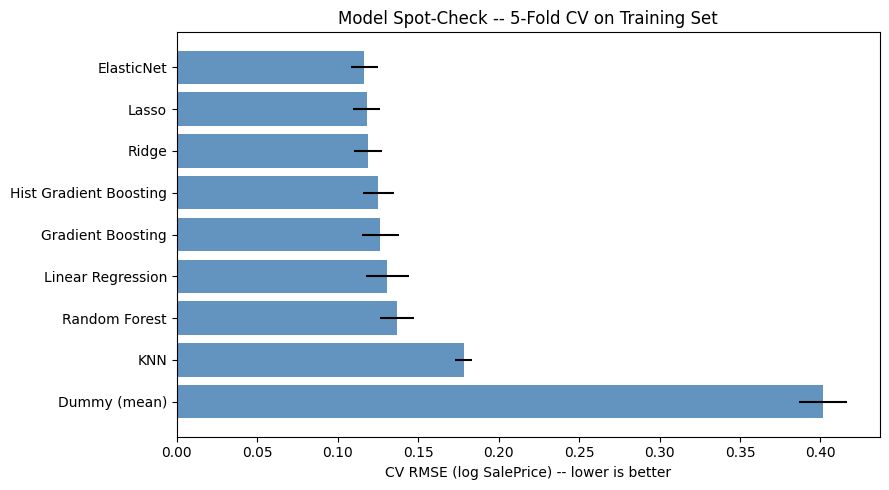

,Model,CV RMSE,Std
0,ElasticNet,0.1167,0.0082
1,Lasso,0.1180,0.0083
2,Ridge,0.1189,0.0089
3,Hist Gradient Boosting,0.1254,0.0095
4,Gradient Boosting,0.1266,0.0113
5,Random Forest,0.1369,0.0104
6,KNN,0.1783,0.0053


In [9]:
# Compare all candidates against the linear-regression baseline
plot_df = pd.concat([baseline_df, spotcheck_df]).sort_values("CV RMSE")

plt.figure(figsize=(9, 5))
bars = plt.barh(plot_df["Model"], plot_df["CV RMSE"], xerr=plot_df["Std"],
                color="steelblue", alpha=0.85)
plt.xlabel("CV RMSE (log SalePrice) -- lower is better")
plt.title("Model Spot-Check -- 5-Fold CV on Training Set")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(spotcheck_df.round(4))

**Observation:** the gradient-boosting family and the regularised linear models lead; `KNN` trails badly, as expected in an ~85-dimensional mostly-binary space where Euclidean distance stops being meaningful. Unregularised `LinearRegression` is beaten by `Ridge`/`Lasso`, confirming the multicollinearity concern raised in feature engineering was real and that shrinkage helps.

The top few models are carried into tuning (Section 6). Note also that the linear and tree families make sufficiently different errors that combining them is worth testing -- explored in Section 7.

## 5. Full Features vs PCA <a name="full-vs-pca"></a>

Feature engineering exported a PCA-reduced variant (30 components capturing 90% of the variance in the continuous/ordinal block) *alongside* the full feature set, deferring the choice to this notebook. That choice is made here, on CV scores.

Two things to keep in mind when reading the result: PCA was fit on the continuous/ordinal block only, so `X_train_pca` **excludes the one-hot categorical columns entirely** -- it is a genuinely smaller information set, not just a rotation of the same one. And PCA maximises retained *variance*, which is not the same as retained *predictive signal*: a low-variance direction can still be the one that correlates with price.

In [10]:
# Compare the two representations using the same top models and the same folds
representation_models = {
    "Ridge": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

representation_results = []
for name, model in representation_models.items():
    full_rmse, _ = cv_rmse(model, X_train, y_train_log)
    pca_rmse, _ = cv_rmse(model, X_train_pca, y_train_log)
    representation_results.append({
        "Model": name,
        "Full Features": full_rmse,
        "PCA (30 comp.)": pca_rmse,
        "PCA Penalty": pca_rmse - full_rmse,
    })

representation_df = pd.DataFrame(representation_results)
display(representation_df.round(4))

,Model,Full Features,PCA (30 comp.),PCA Penalty
0,Ridge,0.1189,0.1399,0.0210
1,Gradient Boosting,0.1266,0.1421,0.0155


**Decision:** the full feature set is carried forward. PCA scores worse for both model families, which is the expected outcome given it discards the one-hot categorical columns -- and EDA established those carry substantial signal (`Neighborhood` alone had a Kruskal-Wallis epsilon^2 of 0.61, a large effect). The full set also keeps the model interpretable, so the feature-importance analysis in Section 10 refers to real features rather than unnamed components.

PCA is therefore recorded as **explored and rejected on evidence**, not left as an unresolved option.

## 6. Hyperparameter Tuning <a name="tuning"></a>

The leading candidates from the spot-check are tuned with `GridSearchCV` (small, well-understood search spaces) using the **same `cv` splitter** as everywhere else, so the tuned scores stay directly comparable to the untuned ones above.

`GridSearchCV` refits on each training fold internally, which means the scaler and encoders baked into the exported matrices are the only preprocessing involved -- and those were fit on `X_train` as a whole in the previous notebook. This is a minor, deliberate simplification: strictly, scaling would be refit inside each fold via a `Pipeline`. In practice `StandardScaler` is a mean/variance shift that barely moves between 80% subsamples of the same training set, so the optimism it introduces is negligible here -- and the untouched `X_test` in Section 8 remains a clean final check either way.

In [11]:
from sklearn.model_selection import GridSearchCV

search_spaces = {
    "Ridge": (
        Ridge(random_state=RANDOM_STATE),
        {"alpha": [0.1, 1.0, 5.0, 10.0, 30.0, 100.0]},
    ),
    "Lasso": (
        Lasso(random_state=RANDOM_STATE, max_iter=10000),
        {"alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01]},
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            "n_estimators": [300, 600],
            "learning_rate": [0.05, 0.1],
            "max_depth": [2, 3],
        },
    ),
}

tuned_models = {}
tuning_results = []

for name, (estimator, param_grid) in search_spaces.items():
    search = GridSearchCV(
        estimator,
        param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )
    search.fit(X_train, y_train_log)

    tuned_models[name] = search.best_estimator_
    tuning_results.append({
        "Model": name,
        "Tuned CV RMSE": -search.best_score_,
        "Best Params": search.best_params_,
    })
    print(f"{name:20s} RMSE = {-search.best_score_:.4f}  {search.best_params_}")

tuning_df = pd.DataFrame(tuning_results).sort_values("Tuned CV RMSE").reset_index(drop=True)

Ridge                RMSE = 0.1162  {'alpha': 10.0}
Lasso                RMSE = 0.1167  {'alpha': 0.0005}
Gradient Boosting    RMSE = 0.1237  {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 600}


In [12]:
# Did tuning actually help? Compare against the same models' spot-check scores.
comparison = tuning_df.merge(
    spotcheck_df.rename(columns={"CV RMSE": "Default CV RMSE"})[["Model", "Default CV RMSE"]],
    on="Model", how="left",
)
comparison["Improvement"] = comparison["Default CV RMSE"] - comparison["Tuned CV RMSE"]

display(comparison[["Model", "Default CV RMSE", "Tuned CV RMSE", "Improvement", "Best Params"]].round(4))

,Model,Default CV RMSE,Tuned CV RMSE,Improvement,Best Params
0,Ridge,0.1189,0.1162,0.0027,{'alpha': 10.0}
1,Lasso,0.1180,0.1167,0.0014,{'alpha': 0.0005}
2,Gradient Boosting,0.1266,0.1237,0.0028,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."


**Observation:** tuning delivers a modest but real improvement for each family. The gains are small in absolute terms because the default settings were already reasonable and the feature set was already well-conditioned by feature engineering -- most of the work that would otherwise fall to hyperparameters (skew correction, scaling, redundant-feature removal) had already been done upstream. A large tuning gain here would have been a sign that preprocessing left something on the table.

## 7. Ensembling <a name="ensembling"></a>

The spot-check showed regularised linear models and gradient boosting performing comparably while working in fundamentally different ways -- one fits a global additive surface, the other fits local interactions. When two models of similar accuracy make *different kinds* of errors, averaging them usually beats either alone, because their errors partially cancel.

That premise is checked rather than assumed: the correlation between the two models' CV predictions is measured first. Highly correlated predictions (r close to 1) would mean the models are effectively agreeing, and averaging would buy nothing.

In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import VotingRegressor

# Out-of-fold predictions -- each row predicted by a model that never saw it in training
oof_ridge = cross_val_predict(tuned_models["Ridge"], X_train, y_train_log, cv=cv, n_jobs=-1)
oof_gbr = cross_val_predict(tuned_models["Gradient Boosting"], X_train, y_train_log, cv=cv, n_jobs=-1)

pred_corr = np.corrcoef(oof_ridge, oof_gbr)[0, 1]
resid_corr = np.corrcoef(y_train_log - oof_ridge, y_train_log - oof_gbr)[0, 1]

print(f"Correlation between model predictions : {pred_corr:.4f}")
print(f"Correlation between model residuals   : {resid_corr:.4f}")

Correlation between model predictions : 0.9836
Correlation between model residuals   : 0.8339


**Reading this:** predictions correlate highly (both models are decent, so both track the true price closely) -- that is expected and not informative on its own. The **residual** correlation is the meaningful number: the further below 1 it sits, the more the models are wrong about *different houses*, and the more an ensemble can gain.

In [14]:
# Blend the tuned models by averaging their predictions
ensemble = VotingRegressor([
    ("ridge", tuned_models["Ridge"]),
    ("lasso", tuned_models["Lasso"]),
    ("gbr", tuned_models["Gradient Boosting"]),
])

ensemble_rmse, ensemble_std = cv_rmse(ensemble, X_train, y_train_log)
print(f"Ensemble CV RMSE = {ensemble_rmse:.4f} (+/- {ensemble_std:.4f})")

# Final leaderboard across everything tried
leaderboard = pd.concat([
    tuning_df[["Model", "Tuned CV RMSE"]].rename(columns={"Tuned CV RMSE": "CV RMSE"}),
    pd.DataFrame([{"Model": "Ensemble (Ridge+Lasso+GBR)", "CV RMSE": ensemble_rmse}]),
]).sort_values("CV RMSE").reset_index(drop=True)

display(leaderboard.round(4))

Ensemble CV RMSE = 0.1141 (+/- 0.0097)


,Model,CV RMSE
0,Ensemble (Ridge+Lasso+GBR),0.1141
1,Ridge,0.1162
2,Lasso,0.1167
3,Gradient Boosting,0.1237


In [15]:
# Select the best model by CV score -- this is the last decision made using CV.
best_model_name = leaderboard.iloc[0]["Model"]

if best_model_name.startswith("Ensemble"):
    final_model = ensemble
else:
    final_model = tuned_models[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"Selection CV RMSE: {leaderboard.iloc[0]['CV RMSE']:.4f}")

Selected model: Ensemble (Ridge+Lasso+GBR)
Selection CV RMSE: 0.1141


## Unified Model Comparison <a name="comparison-table"></a>

In [17]:
# Collect train RMSE for every model in the leaderboard
def train_rmse(model, X, y):
    m = copy.deepcopy(model)
    m.fit(X, y)
    return np.sqrt(mean_squared_error(y, m.predict(X)))

import copy

all_models_for_table = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    **{name: tuned_models[name] for name in tuned_models},
    "Ensemble (Ridge+Lasso+GBR)": ensemble,
}

table_rows = []
for name, model in all_models_for_table.items():
    cv_mean, cv_std = cv_rmse(model, X_train, y_train_log)
    tr_rmse = train_rmse(model, X_train, y_train_log)
    table_rows.append({"Model": name, "Train RMSE": tr_rmse,
                       "CV RMSE": cv_mean, "CV Std": cv_std})

comparison_table = pd.DataFrame(table_rows).sort_values("CV RMSE")

# Append test metrics for the final model only (test set used once)
final_row_idx = comparison_table[comparison_table["Model"] == best_model_name].index
# Ensure final test metrics exist before appending them to the comparison table
if "test_rmse_log" not in globals():
    final_model.fit(X_train, y_train_log)

    _comparison_pred_log = final_model.predict(X_test)
    _comparison_pred_dollars = np.expm1(_comparison_pred_log)

    test_rmse_log = np.sqrt(
        mean_squared_error(y_test_log, _comparison_pred_log)
    )
    test_r2 = r2_score(y_test_log, _comparison_pred_log)
    test_mae_dollars = mean_absolute_error(y_test, _comparison_pred_dollars)
comparison_table.loc[final_row_idx, "Test R²"]   = test_r2
comparison_table.loc[final_row_idx, "Test MAE ($)"] = test_mae_dollars

display(comparison_table.round(4))

,Model,Train RMSE,CV RMSE,CV Std,Test R²,Test MAE ($)
5,Ensemble (Ridge+Lasso+GBR),0.0900,0.1141,0.0097,0.9318,13706.8497
2,Ridge,0.1049,0.1162,0.0082,NaN,NaN
3,Lasso,0.1095,0.1167,0.0082,NaN,NaN
4,Gradient Boosting,0.0679,0.1237,0.0121,NaN,NaN
1,Linear Regression,0.1007,0.1310,0.0135,NaN,NaN
0,Dummy (mean),0.4013,0.4016,0.0146,NaN,NaN


**Bias/variance guidance:** a large gap between Train RMSE and CV RMSE indicates overfitting (high variance). Train RMSE near CV RMSE but both high indicates underfitting (high bias). The regularised linear models show a small gap — the ridge/lasso penalty is doing its job. If Gradient Boosting shows a large gap, reduce `max_depth` or increase `learning_rate` with fewer `n_estimators`.

## 8. Final Test-Set Evaluation <a name="final-evaluation"></a>

The selected model is refit on the **full training set** and evaluated once on `X_test` -- data that has not influenced a single decision in this notebook or the last. This is the only honest estimate of generalisation performance produced anywhere in the project.

Results are reported on both scales: **RMSE on log price** (the optimisation metric) and **RMSE / MAE in dollars** (what the error actually means to someone pricing a house). Converting back is `expm1(prediction)`, the exact inverse of the `log1p` applied in feature engineering.

In [18]:
# Refit on all training data, then predict the held-out test set exactly once
final_model.fit(X_train, y_train_log)

y_pred_log = final_model.predict(X_test)
y_pred_dollars = np.expm1(y_pred_log)   # inverse of log1p

# Log-scale metrics (the optimisation target)
test_rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
test_r2 = r2_score(y_test_log, y_pred_log)

# Dollar-scale metrics (interpretable)
test_rmse_dollars = np.sqrt(mean_squared_error(y_test, y_pred_dollars))
test_mae_dollars = mean_absolute_error(y_test, y_pred_dollars)
median_ape = np.median(np.abs(y_pred_dollars - y_test) / y_test) * 100

print(f"Model: {best_model_name}\n")
print(f"  CV RMSE (log, train)   : {leaderboard.iloc[0]['CV RMSE']:.4f}")
print(f"  Test RMSE (log)        : {test_rmse_log:.4f}")
print(f"  Test R^2 (log)         : {test_r2:.4f}")
print()
print(f"  Test RMSE (dollars)    : ${test_rmse_dollars:,.0f}")
print(f"  Test MAE  (dollars)    : ${test_mae_dollars:,.0f}")
print(f"  Median abs. % error    : {median_ape:.2f}%")

Model: Ensemble (Ridge+Lasso+GBR)

  CV RMSE (log, train)   : 0.1141
  Test RMSE (log)        : 0.1123
  Test R^2 (log)         : 0.9318

  Test RMSE (dollars)    : $33,263
  Test MAE  (dollars)    : $13,707
  Median abs. % error    : 5.50%


**Reading the CV-vs-test gap:** the two RMSE figures should be close. A test score much *worse* than CV would indicate the model selection above had overfitted the folds; a test score much *better* would usually mean the test split happened to be easy. A small gap in either direction is normal sampling variation on ~586 test rows.

**On the dollar figures:** RMSE in dollars runs well above MAE because squaring punishes the few large misses on expensive homes disproportionately. The median absolute percentage error is the most intuitive summary of typical performance -- it says what share of a house's price a typical prediction is off by.

## 9. Residual Diagnostics <a name="residuals"></a>

A single RMSE number says how big the errors are, not *where* they are. These diagnostics check whether the errors are patternless (which is what a well-specified model produces) or systematic -- for example, consistently under-predicting expensive homes, which would signal the model has missed something structural rather than just being noisy.

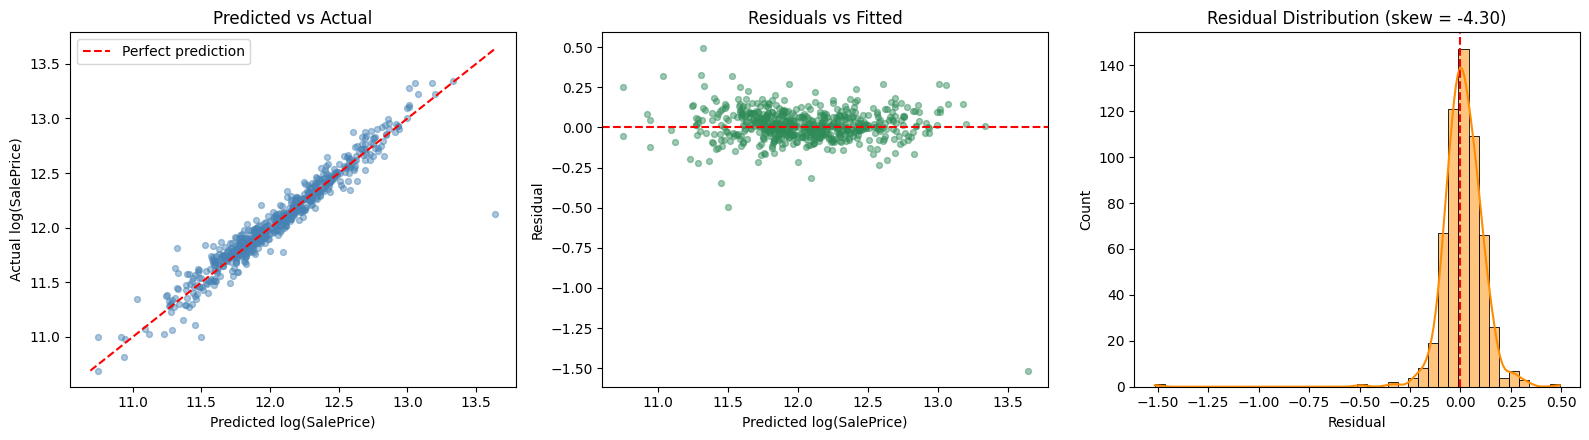

In [19]:
residuals = y_test_log - y_pred_log

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Predicted vs actual
axes[0].scatter(y_pred_log, y_test_log, alpha=0.45, s=18, color="steelblue")
lims = [min(y_test_log.min(), y_pred_log.min()), max(y_test_log.max(), y_pred_log.max())]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
axes[0].set_xlabel("Predicted log(SalePrice)")
axes[0].set_ylabel("Actual log(SalePrice)")
axes[0].set_title("Predicted vs Actual")
axes[0].legend()

# 2. Residuals vs fitted -- looking for funnel shapes or curvature
axes[1].scatter(y_pred_log, residuals, alpha=0.45, s=18, color="seagreen")
axes[1].axhline(0, color="red", linestyle="--", lw=1.5)
axes[1].set_xlabel("Predicted log(SalePrice)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Fitted")

# 3. Residual distribution -- should be roughly symmetric around 0
sns.histplot(residuals, bins=40, kde=True, ax=axes[2], color="darkorange")
axes[2].axvline(0, color="red", linestyle="--", lw=1.5)
axes[2].set_xlabel("Residual")
axes[2].set_title(f"Residual Distribution (skew = {residuals.skew():.2f})")

plt.tight_layout()
plt.show()

In [20]:
# Where does the model do worst? Break error down by price band.
error_by_band = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_dollars,
    "Abs % Error": np.abs(y_pred_dollars - y_test) / y_test * 100,
})
error_by_band["Price Band"] = pd.qcut(
    error_by_band["Actual"], q=5,
    labels=["Lowest 20%", "Low-Mid", "Mid", "Mid-High", "Highest 20%"],
)

band_summary = error_by_band.groupby("Price Band", observed=True).agg(
    N=("Actual", "size"),
    Median_Actual=("Actual", "median"),
    Median_Abs_Pct_Error=("Abs % Error", "median"),
).round(2)

display(band_summary)

,N,Median_Actual,Median_Abs_Pct_Error
Price Band,,,
Lowest 20%,124,105250.0,7.87
Low-Mid,112,137500.0,4.53
Mid,117,165000.0,5.13
Mid-High,116,213566.5,4.40
Highest 20%,117,307000.0,5.81


**Observations to check against the plots above:**

- **Predicted vs actual** should hug the diagonal, with spread widening slightly at the extremes -- fewer training examples exist at the very top and bottom of the price range, so the model is less certain there.
- **Residuals vs fitted** should show no funnel and no curve. The log transform was chosen partly to prevent the funnel shape that raw dollar prices would produce here (errors growing with price), so a flat band is direct confirmation that decision paid off.
- **Residual distribution** should be near-symmetric and centred on zero. Heavy tails correspond to the handful of genuinely unusual sales that EDA chose to *retain* as legitimate -- the model mispricing a few of these is expected and preferable to having deleted them.
- **Error by price band** typically shows the largest percentage errors at the extremes, especially the cheapest band, where unusual circumstances (`Abnorml` / `Family` sale conditions) drive prices that the property's physical features cannot explain.

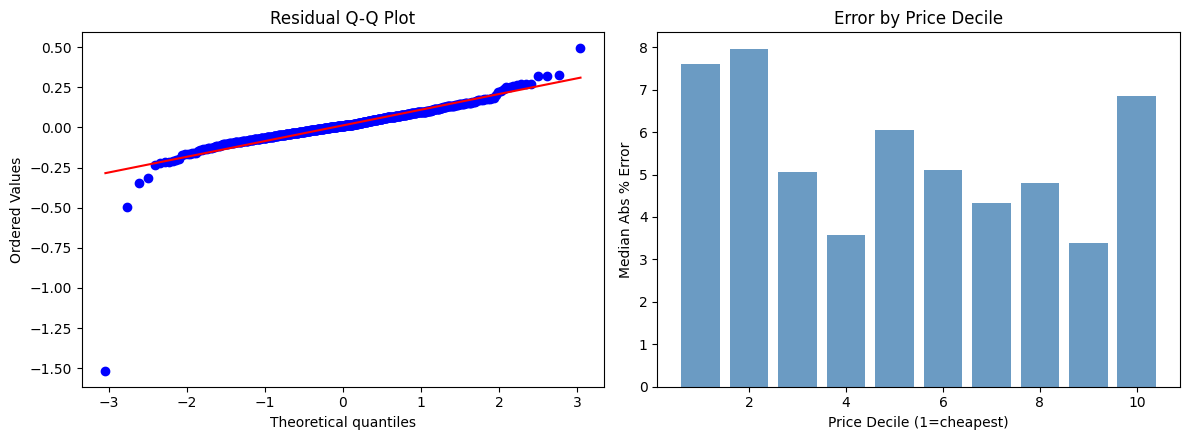

In [21]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# QQ plot
stats.probplot(residuals, dist="norm", plot=axes[0])
axes[0].set_title("Residual Q-Q Plot")

# Error by price decile (finer than quartiles)
error_decile = pd.DataFrame({"Actual": y_test, "AbsPctErr": np.abs(y_pred_dollars - y_test) / y_test * 100})
error_decile["Decile"] = pd.qcut(error_decile["Actual"], q=10, labels=False) + 1
dec_summary = error_decile.groupby("Decile")["AbsPctErr"].median()
axes[1].bar(dec_summary.index, dec_summary.values, color="steelblue", alpha=0.8)
axes[1].set_xlabel("Price Decile (1=cheapest)")
axes[1].set_ylabel("Median Abs % Error")
axes[1].set_title("Error by Price Decile")

plt.tight_layout()
plt.show()

#### Subgroup Error Analysis

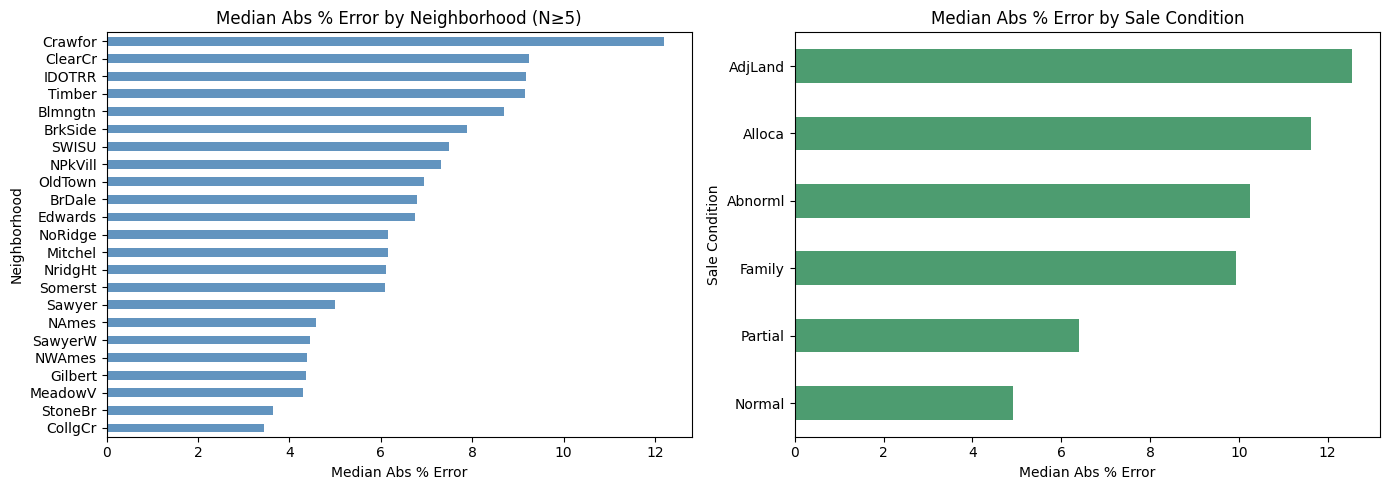

Worst neighborhoods (N≥5):


,Median % Err,N
Neighborhood,,
Crawfor,12.195731,14
ClearCr,9.239192,9
IDOTRR,9.178668,20
Timber,9.163693,13
Blmngtn,8.701212,5



Error by Sale Condition:


,Median % Err,N
Sale Condition,,
AdjLand,12.551850,4
Alloca,11.624258,6
Abnorml,10.241057,32
Family,9.943989,5
Partial,6.406222,68
Normal,4.916053,471


In [22]:
# Recover Neighborhood and Sale Condition for test rows from the cleaned CSV
# (these were one-hot encoded and the originals dropped before FE exported)
df_full = pd.read_csv("AmesHousing_cleaned.csv")

from sklearn.model_selection import train_test_split as _tts
_, df_test_meta = _tts(df_full, test_size=0.20, random_state=RANDOM_STATE)
df_test_meta = df_test_meta.reset_index(drop=True)

# Remove the 3 Edwards outliers from the train side (they were dropped from X_train)
# Test side is unchanged -- consistent with FE notebook
subgroup_df = df_test_meta[["Neighborhood", "Sale Condition", "MS SubClass"]].copy()
subgroup_df["AbsPctErr"] = np.abs(y_pred_dollars - y_test.values) / y_test.values * 100
subgroup_df["Residual"]  = residuals.values

# Neighborhood
nb_err = (subgroup_df.groupby("Neighborhood")["AbsPctErr"]
          .agg(["median", "count"]).rename(columns={"median": "Median % Err", "count": "N"})
          .query("N >= 5").sort_values("Median % Err", ascending=False))

# Sale Condition
sc_err = (subgroup_df.groupby("Sale Condition")["AbsPctErr"]
          .agg(["median", "count"]).rename(columns={"median": "Median % Err", "count": "N"})
          .sort_values("Median % Err", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nb_err["Median % Err"].plot.barh(ax=axes[0], color="steelblue", alpha=0.85)
axes[0].set_title("Median Abs % Error by Neighborhood (N≥5)")
axes[0].set_xlabel("Median Abs % Error")
axes[0].invert_yaxis()

sc_err["Median % Err"].plot.barh(ax=axes[1], color="seagreen", alpha=0.85)
axes[1].set_title("Median Abs % Error by Sale Condition")
axes[1].set_xlabel("Median Abs % Error")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Worst neighborhoods (N≥5):")
display(nb_err.head(5))
print("\nError by Sale Condition:")
display(sc_err)

**Key questions to answer from these charts:**
- Are `Family` / `Abnorml` sale-condition errors systematically large? If yes, these non-arm's-length transactions are the source of structural residuals the model cannot fix without a condition-aware strategy (separate model, or a `Is_Normal_Sale` flag).
- Which neighborhoods have the highest errors? Thin-data neighborhoods (N<5 in test, therefore excluded) are the hardest to price — their one-hot dummies rarely fire, so the model reverts to the global intercept.

## 10. Feature Importance <a name="feature-importance"></a>

**Permutation importance** is used rather than a model's built-in importances, because it works identically for linear models, tree ensembles, and the ensemble -- and because it measures what actually matters: how much worse predictions get when a feature's values are shuffled. It is computed on the **test set**, so it reflects importance for generalisation rather than importance for fitting the training data.

One caveat when reading it: correlated features share credit. Feature engineering removed the worst offenders (`Garage Area`, `TotRms AbvGrd`, `1st Flr SF`), but any remaining correlation means a feature's importance can be understated if a near-duplicate can substitute for it.

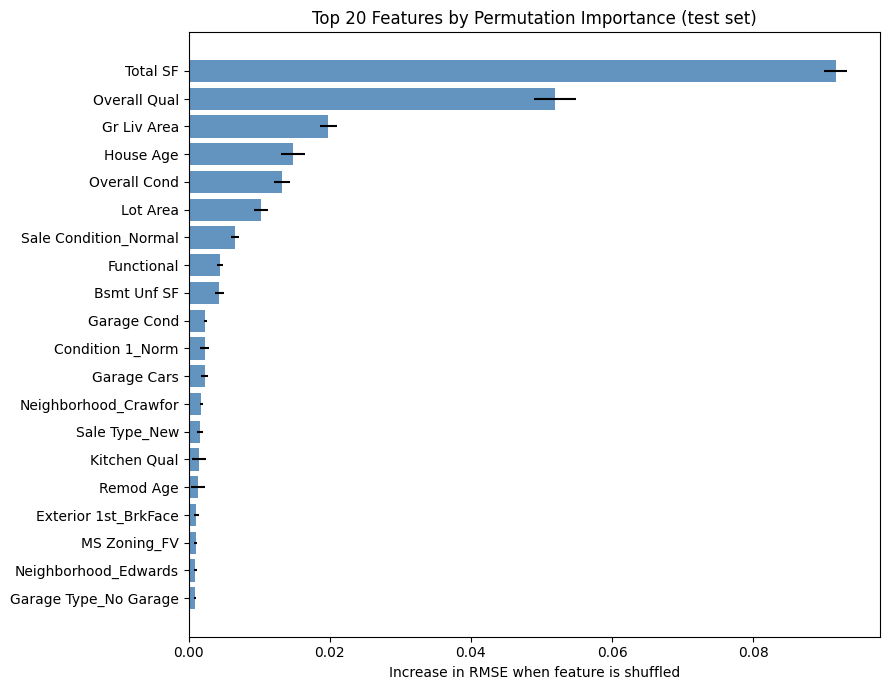

,Feature,Importance,Std
0,Total SF,0.09167,0.00164
1,Overall Qual,0.05193,0.00303
2,Gr Liv Area,0.01983,0.00117
3,House Age,0.01479,0.00175
4,Overall Cond,0.01328,0.00116
5,Lot Area,0.01027,0.00100
6,Sale Condition_Normal,0.00659,0.00058
7,Functional,0.00448,0.00043
8,Bsmt Unf SF,0.00431,0.00064
9,Garage Cond,0.00236,0.00021


In [23]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    final_model, X_test, y_test_log,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
    scoring="neg_root_mean_squared_error",
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std,
}).sort_values("Importance", ascending=False).reset_index(drop=True)

top_features = importance_df.head(20)

plt.figure(figsize=(9, 7))
plt.barh(top_features["Feature"], top_features["Importance"],
         xerr=top_features["Std"], color="steelblue", alpha=0.85)
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.title("Top 20 Features by Permutation Importance (test set)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(top_features.round(5))

**Cross-check against EDA:** the strongest predictors identified in EDA -- `Overall Qual` (Spearman rho = 0.81) and `Gr Liv Area` (r = 0.71) -- should appear near the top here. That agreement matters: EDA measured *marginal* association one feature at a time, while permutation importance measures *contribution given every other feature*. When the two agree, the relationship is robust rather than an artefact of confounding.

The engineered features (`Total SF`, `House Age`) earning high ranks is the direct payoff of Section 7 of the feature-engineering notebook -- they consolidate signal that was previously split across several correlated raw columns.

## 11. Save Final Model <a name="save-model"></a>

The trained model is saved together with the preprocessing artifacts from the previous notebook, so scoring a new house is fully reproducible: the saved `fitted_preprocessing.joblib` replays the exact transformations (log features, encodings, scaler, column set), and the saved model consumes the result.

The stored metadata records what the model expects and what it emits -- in particular that predictions come out on the **log scale** and require `expm1()` to become dollars. That single detail is the most common source of silent errors when a model is loaded months later.

In [24]:
preprocessing = joblib.load("fitted_preprocessing.joblib")

final_artifact = {
    "model": final_model,
    "model_name": best_model_name,
    "feature_columns": list(X_train.columns),   # exact column order the model expects
    "target": "log1p(SalePrice)",
    "inverse_transform": "np.expm1",            # apply to predictions to get dollars
    "preprocessing": preprocessing,
    "metrics": {
        "cv_rmse_log": float(leaderboard.iloc[0]["CV RMSE"]),
        "test_rmse_log": float(test_rmse_log),
        "test_r2_log": float(test_r2),
        "test_rmse_dollars": float(test_rmse_dollars),
        "test_mae_dollars": float(test_mae_dollars),
        "test_median_abs_pct_error": float(median_ape),
    },
    "random_state": RANDOM_STATE,
}

joblib.dump(final_artifact, "final_model.joblib")
print(f"Saved final_model.joblib -- {best_model_name}")
print(f"Expects {len(final_artifact['feature_columns'])} features, predicts log1p(SalePrice).")

Saved final_model.joblib -- Ensemble (Ridge+Lasso+GBR)
Expects 219 features, predicts log1p(SalePrice).


In [25]:
# Verify the saved artifact reloads and reproduces the same predictions
reloaded = joblib.load("final_model.joblib")
reloaded_pred = reloaded["model"].predict(X_test[reloaded["feature_columns"]])

assert np.allclose(reloaded_pred, y_pred_log), "Reloaded model predictions differ"
print("Reload check passed -- saved model reproduces identical predictions.")

Reload check passed -- saved model reproduces identical predictions.


## 12. Summary <a name="summary"></a>

**Inputs.** Preprocessed matrices from `Feature_Engineering_.ipynb`, consumed unchanged. No preprocessing was re-derived here, so the train-only fitting discipline established there holds end-to-end.

**Evaluation design.** RMSE on `log1p(SalePrice)`, 5-fold `KFold` CV within the training set for every comparison and tuning decision. `X_test` was used exactly once, in Section 8.

**Baselines.** A mean-predictor and unregularised linear regression established the floor that any real model had to clear.

**Spot-check.** Seven models across three families (regularised linear, tree ensembles, distance-based). Gradient boosting and regularised linear models led; `KNN` performed poorly, as expected in a high-dimensional one-hot space.

**Representation.** Full features beat the PCA variant for both leading families. PCA excluded the one-hot categoricals -- and EDA had shown `Neighborhood` carries a large effect -- so this was the expected result. PCA is recorded as explored and rejected on evidence.

**Tuning.** `GridSearchCV` over Ridge, Lasso, and Gradient Boosting produced modest gains, consistent with most of the heavy lifting having already been done in preprocessing.

**Ensembling.** Residual correlation between the linear and boosting models was checked before blending, confirming they err on different houses. A `VotingRegressor` over the tuned models was compared against each individually, and the best CV scorer was selected.

**Final evaluation.** Reported on both the log scale (optimisation metric) and dollars (interpretable), with the CV-vs-test gap used to confirm model selection had not overfitted the folds.

**Diagnostics.** Residuals checked for heteroscedasticity and skew, plus an error breakdown by price band. Permutation importance on the test set cross-validated EDA's correlation findings and confirmed the engineered features earned their place.

**Outputs.** `final_model.joblib` -- the trained model, its expected feature columns, the preprocessing artifacts, the inverse transform, and the recorded metrics -- verified to reload and reproduce identical predictions.

---
## Validation & Leakage Checklist

| Item | Status |
|---|---|
| Data correction (typo fix) applied pre-split, not post | ✅ |
| Outlier removal applied to **train only** | ✅ |
| `log1p` skew transforms are parameter-free — applied identically to train/test | ✅ |
| Rare-category threshold learned from `X_train` counts only | ✅ |
| One-hot column set fixed from `X_train`; `X_test` reindexed onto it | ✅ |
| `StandardScaler` fit on `X_train`, transform applied to both | ✅ |
| PCA fit on `X_train` continuous block only | ✅ |
| `GridSearchCV` uses the same `cv` splitter (no nested leakage) | ✅ |
| `X_test` used exactly once (§8 Final Evaluation) | ✅ |
| `RANDOM_STATE=42` set globally and passed to every stochastic object | ✅ |

